## Verizon Repair Times: Permutation Tests

ILEC - incumbent local exchange carrier (Verizon)<br>
CLEC - competing local exchange carrier

In this notebook, we run a sampled permutation test to investigate whether CLEC repair times take longer than the ILEC repair times. We start by observing the totality of the data, then we move to remove outliers due to the significant tail of repair times.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

data = pd.read_csv("../Data/Verizon.csv")

print(data.head())
print(data["Group"].unique())

    Time Group
0  17.50  ILEC
1   2.40  ILEC
2   0.00  ILEC
3   0.65  ILEC
4  22.23  ILEC
['ILEC' 'CLEC']


In [71]:
ilec = data[data["Group"] == "ILEC"]["Time"]
clec = data[data["Group"] == "CLEC"]["Time"]

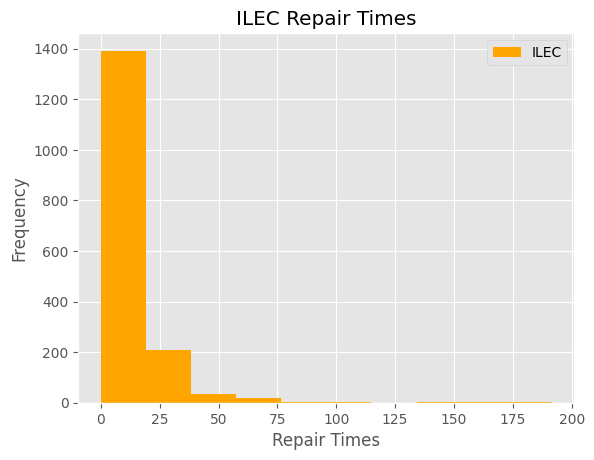

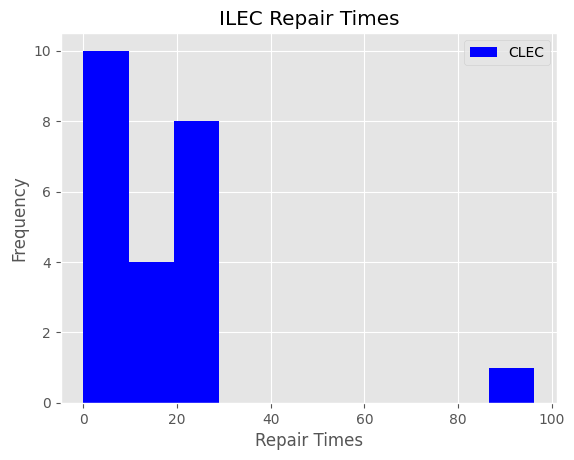

In [72]:
# Histograms of repair times
plt.hist(ilec, color="orange", label="ILEC")
plt.title("ILEC Repair Times")
plt.xlabel("Repair Times")
plt.ylabel("Frequency")
plt.legend()
plt.show()

plt.hist(clec, color="blue", label="CLEC")
plt.title("ILEC Repair Times")
plt.xlabel("Repair Times")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Hypotheses
The test statistic is the difference between the mean repair times.

$H_0: \mu_{CLEC}=\mu_{ILEC}$<br>
$H_A: \mu_{CLEC}>\mu_{ILEC}$

In [73]:
# Observed test statistic
t_obs = ilec.mean() - clec.mean()

print(f"ILEC data size: {len(ilec)}")
print(f"CLEC data size: {len(clec)}")
print(f"Observed test statistic: {t_obs}")

ILEC data size: 1664
CLEC data size: 23
Observed test statistic: -8.097519857859533


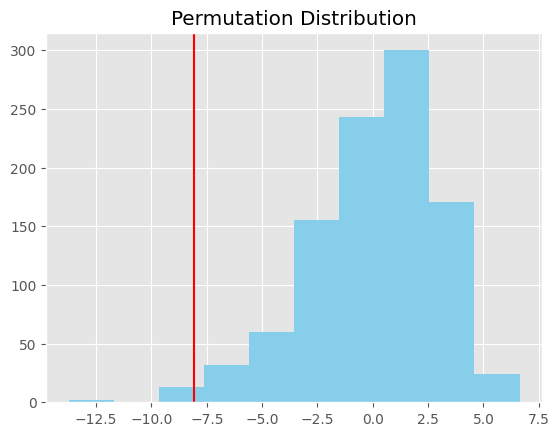

In [74]:
pool_times = data["Time"]

N = 1000

perm_t = []
for i in range(N):
    t_clec = pool_times.sample(len(clec))
    t_ilec = pool_times.drop(t_clec.index)
    
    t_stat = t_ilec.mean() - t_clec.mean()
    perm_t.append(t_stat)
    
plt.hist(perm_t, color="skyblue")
plt.axvline(t_obs, color="red")
plt.title("Permutation Distribution")
plt.show()


In [75]:
# Compute p-value
perm_t = np.array(perm_t)
p_val = (np.sum(perm_t <= t_obs) + 1) / (len(perm_t) + 1)
print(f"P-Value: {p_val}")

P-Value: 0.012987012987012988


Due to the significant outliers in the repair times, the test statistic is changed to the difference in median repair times.

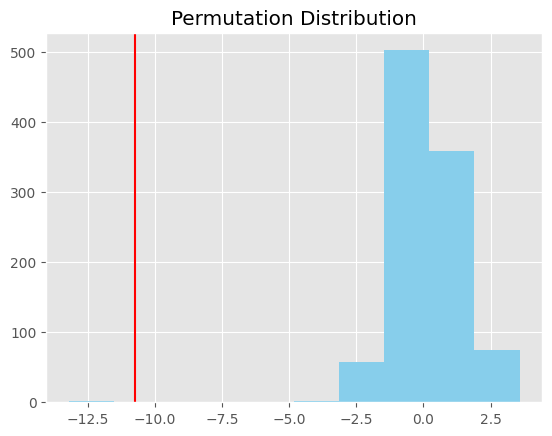

P-Value: 0.002997002997002997


In [76]:
t_obs = ilec.median() - clec.median()

N = 1000

pool_times = data["Time"]
perm_t = []
for i in range(N):
    t_clec = pool_times.sample(len(clec))
    t_ilec = pool_times.drop(t_clec.index)
    
    t_stat = t_ilec.median() - t_clec.median()
    perm_t.append(t_stat)

plt.hist(perm_t, color="skyblue")
plt.axvline(t_obs, color="red")
plt.title("Permutation Distribution")
plt.show()

perm_t = np.array(perm_t)
p_val = (np.sum(perm_t <= t_obs) + 1) / (len(perm_t) + 1)
print(f"P-Value: {p_val}")